# TODO
Load Dataset of Glorys Area1

In [1]:
import os
import numpy as np
import scipy as sp
import pandas as pd
from datetime import date
import marineHeatWaves as mhw
import netCDF4 as nc
import datetime
import matplotlib.pyplot as plt
from tqdm import notebook
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, Executor

## Load file list

In [ ]:
thetaos=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_new.npy')
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')

In [ ]:
test=thetaos[0,:,-1,-1]
test[0]-2

In [ ]:
depth[test[0]-2-test>0][0]

In [ ]:
depth

In [ ]:
def mld(dat):
    global depth
    if dat[0]-2>dat[-1]:
        return depth[dat[0]-2-dat>0][0]
    else:
        return np.nan
def list_map(dat):
    # pool = ProcessPoolExecutor(max_workers=9)
    # ans=np.array(list(pool.map(mld,dat)))
    # del pool
    ans=np.array(list(map(mld,dat)))
    return ans
def onetime(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    #pool = ProcessPoolExecutor(max_workers=4)
    ans=np.array(list(map(list_map,a)))
    return ans

In [ ]:
pool = ProcessPoolExecutor(max_workers=54)
mlds=np.array(list(pool.map(onetime,thetaos)))
np.save('12_2_mld.npy',mlds)
del pool

In [ ]:
mlds

mld_c

In [72]:
t = np.arange(date(1993,1,1).toordinal(),date(2019,12,31).toordinal()+1)
def mlds(dat):
    global t
    try:
        mhws, clim = mhw.detect(t,dat,climatologyPeriod=[1993,2019])
        return clim['seas']
    except:
        return np.array([np.nan]*9861)
def list_map(dat):
    pool = ProcessPoolExecutor(max_workers=7)
    ans=np.array(list(pool.map(mlds,dat)))
    del pool
    return ans
def onetime(dat):
    ans=np.array(list(map(list_map,dat)))
    return ans

In [ ]:
mld=np.load('12_2_mld.npy')

In [ ]:
a[50,50][np.isnan(a[50,50])]

In [73]:
onetime(a[20:22,20:22,:])

array([[[263.76312565, 265.36726646, 266.80299018, ..., 257.79094742,
         259.99962249, 261.97993175],
        [265.40876709, 267.34151275, 269.14013212, ..., 258.63959505,
         261.05836258, 263.31621897]],

       [[263.08224812, 265.5193594 , 267.84001943, ..., 255.15761572,
         257.91516751, 260.55138907],
        [265.49417332, 267.41930587, 269.24291133, ..., 259.10697965,
         261.33667771, 263.47296675]]])

In [71]:
a[20:22,20:22,:]

array([[[         nan,          nan,          nan, ..., 266.04031372,
         266.04031372, 266.04031372],
        [         nan,          nan,          nan, ..., 318.12741089,
         318.12741089, 318.12741089]],

       [[         nan,          nan, 318.12741089, ..., 266.04031372,
         318.12741089, 266.04031372],
        [         nan,          nan,          nan, ..., 266.04031372,
         266.04031372, 266.04031372]]])

In [ ]:
mhw.detect(t,a[50,50],climatologyPeriod=[1993,2019])

In [ ]:
np.nansum(np.isnan(a[50,50]))

In [46]:
list_map(a[0,20:22,:])

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [62]:
np.sum(np.isnan(a[0,20,:]))

4137

In [ ]:
a=np.swapaxes(mld,0,1)
a=np.swapaxes(a,1,2)

In [74]:
pool = ProcessPoolExecutor(max_workers=6)
ans=np.array(list(pool.map(list_map,a)))
del pool

/lustre/home/yuhanxue/anaconda3/lib/python3.9/site-packages/marineHeatWaves.py:406: RuntimeWarning: invalid value encountered in double_scalars
  mhw['rate_decline'].append((mhw_relSeas[tt_peak] - mhw_relSeas[-1]) / (tt_end-tt_start-tt_peak))
/lustre/home/yuhanxue/anaconda3/lib/python3.9/site-packages/marineHeatWaves.py:406: RuntimeWarning: invalid value encountered in double_scalars
  mhw['rate_decline'].append((mhw_relSeas[tt_peak] - mhw_relSeas[-1]) / (tt_end-tt_start-tt_peak))
/lustre/home/yuhanxue/anaconda3/lib/python3.9/site-packages/marineHeatWaves.py:406: RuntimeWarning: invalid value encountered in double_scalars
  mhw['rate_decline'].append((mhw_relSeas[tt_peak] - mhw_relSeas[-1]) / (tt_end-tt_start-tt_peak))


In [60]:
del pool

NameError: name 'pool' is not defined

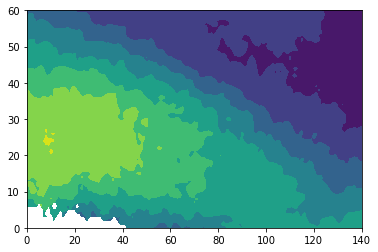

In [75]:
plt.contourf(ans[:,:,5861])

In [76]:
np.save('12_3_mld_clim.npy',ans)

mld_2021_area1

In [7]:
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def mld(dat):
    global depth
    if dat[0]-2>dat[-1]:
        return depth[dat[0]-2-dat>0][0]
    else:
        return np.nan
def list_map(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(mld,dat)))
    del pool
    return ans
def onetime(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map,a)))
    del pool
    return ans

In [2]:
thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")

In [11]:
pool = ProcessPoolExecutor(max_workers=3)
mld2021a1=np.array(list(pool.map(onetime,thetaos2020a1)))
del pool

In [10]:
del pool

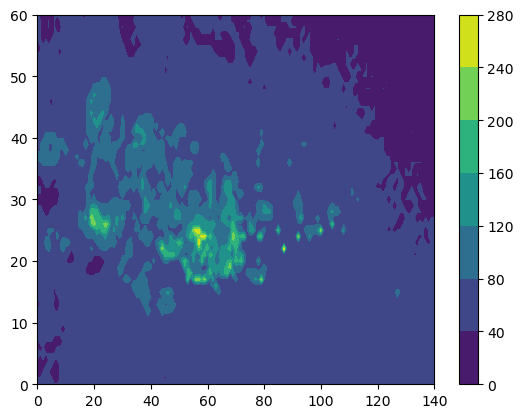

In [18]:
plt.contourf(mld2021a1[2,:,:])
plt.colorbar()